In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

## График числа статей

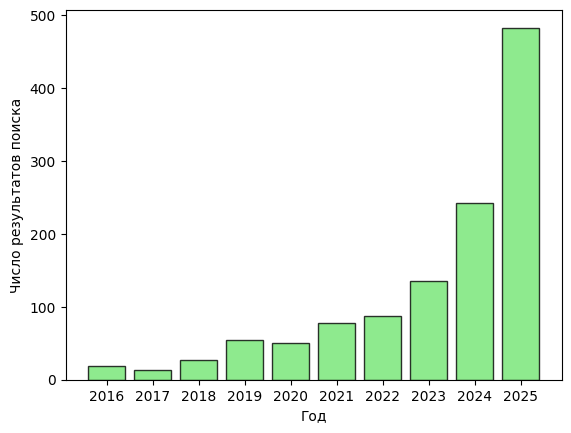

In [4]:
data = [19, 14, 27, 54, 50, 78, 88, 135, 242, 483]
periods = list(map(str, range(2016, 2026)))

plt.bar(periods, height=data, color="#72E572", alpha=0.8, linewidth=1, edgecolor='#000000')
# plt.title("Число публикаций в Google Scholar\nсвязанных с text-to-SQL")
plt.ylabel("Число результатов поиска")
plt.xlabel("Год");

## График изменения топов бенчмарков

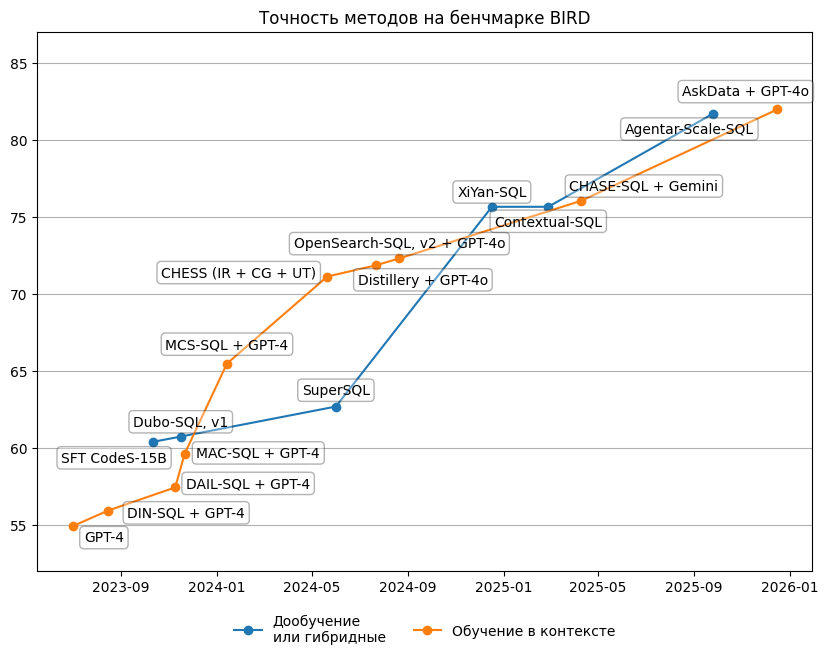

In [50]:
from datetime import date, timedelta
import matplotlib.dates as mdates

bird_data = [
    (date(2023, 7, 1), 54.89, "GPT-4", 'icl'),
    (date(2023, 8, 15), 55.90, "DIN-SQL + GPT-4", 'icl'),
    (date(2023, 10, 12), 60.37, "SFT CodeS-15B", 'ft'),
    (date(2023, 11, 9), 57.41, "DAIL-SQL + GPT-4", 'icl'),
    (date(2023, 11, 16), 60.71, "Dubo-SQL, v1", 'ft'), # hybrid
    (date(2023, 11, 21), 59.59, "MAC-SQL + GPT-4", 'icl'),
    (date(2024, 1, 14), 65.45, "MCS-SQL + GPT-4", "icl"),
    (date(2024, 5, 21), 71.10, "CHESS (IR + CG + UT)", 'icl'),
    (date(2024, 6, 1), 62.66, "SuperSQL", 'ft'),
    (date(2024, 7, 22), 71.83, "Distillery + GPT-4o", 'icl'),
    (date(2024, 8, 21), 72.28, "OpenSearch-SQL, v2 + GPT-4o", 'icl'),
    (date(2024, 12, 17), 75.63, "XiYan-SQL", 'ft'), # hybrid
    (date(2025, 2, 27), 75.63, "Contextual-SQL", 'ft'), # hybrid
    (date(2025, 4, 10), 76.02, "CHASE-SQL + Gemini", 'icl'), 
    (date(2025, 9, 25), 81.67, "Agentar-Scale-SQL", 'ft'), # hybrid
    (date(2025, 12, 16), 81.95, "AskData + GPT-4o", 'icl')
]

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    [line[0] for line in bird_data if line[3] == 'ft'], 
    [line[1] for line in bird_data if line[3] == 'ft'],
    marker='o', label='Дообучение\nили гибридные'
)
ax.plot(
    [line[0] for line in bird_data if line[3] == 'icl'], 
    [line[1] for line in bird_data if line[3] == 'icl'],
    marker='o', label='Обучение в контексте'
)

offsets = [
    (timedelta(days=40), -1),
    (timedelta(days=100), -0.4),
    (-timedelta(days=50), -1.3),
    (timedelta(days=93), 0),
    (timedelta(days=0), 0.7),
    (timedelta(days=94), -0.2),
    (timedelta(days=0), 1),
    (-timedelta(days=113), 0),
    (timedelta(days=0), 0.8),
    (timedelta(days=60), -1.2),
    (timedelta(days=0), 0.7),
    (-timedelta(days=0), 0.7),
    (timedelta(days=0), -1.2),
    (timedelta(days=80), 0.7),
    (-timedelta(days=30), -1.25),
    (-timedelta(days=40), 0.9),
]
for i, line in enumerate(bird_data):
    if i < len(offsets):
        ax.text(
            line[0] + offsets[i][0], line[1] + offsets[i][1], line[2], ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3)
        )
    else:
        ax.text(
            line[0], line[1], line[2], ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3)
        )

ax.grid(True, axis='y')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title("Точность методов на бенчмарке BIRD")
ax.set_ylim(52, 87)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False);

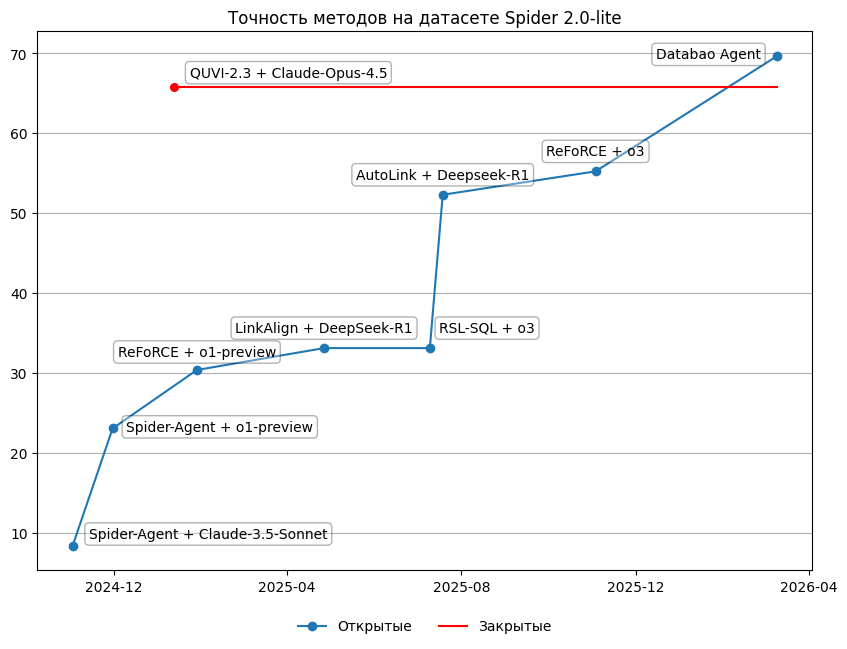

In [24]:
s2lite_data = [
    (date(2024, 11, 2), 8.32, "Spider-Agent + Claude-3.5-Sonnet", 'open'),
    (date(2024, 11, 30), 23.03, "Spider-Agent + o1-preview", 'open'),
    (date(2025, 1, 12), 65.81, "QUVI-2.3 + Claude-Opus-4.5", 'closed'),
    (date(2025, 1, 28), 30.35, "ReFoRCE + o1-preview", 'open'),
    (date(2025, 4, 27), 33.09, "LinkAlign + DeepSeek-R1", 'open'),
    (date(2025, 7, 10), 33.09, "RSL-SQL + o3", 'open'),
    (date(2025, 7, 19), 52.28, "AutoLink + Deepseek-R1", 'open'),
    (date(2025, 11, 3), 55.21, "ReFoRCE + o3", 'open'),
    (date(2026, 3, 10), 69.65, "Databao Agent", 'open')
]

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    [line[0] for line in s2lite_data if line[3] == 'open'], 
    [line[1] for line in s2lite_data if line[3] == 'open'],
    marker='o', label='Открытые'
)
ax.plot(
    [s2lite_data[i][0] for i in range(2, len(s2lite_data))],
    [s2lite_data[2][1] for _ in range(2, len(s2lite_data))],
    label='Закрытые', color='red'
)
ax.scatter(s2lite_data[2][0], s2lite_data[2][1], color='red', s=30, zorder=5)


offsets = [
    (timedelta(days=95), 1),
    (timedelta(days=75), -0.3),
    (timedelta(days=80), 1.25),
    (timedelta(days=0), 1.75),
    (timedelta(days=0), 2),
    (timedelta(days=40), 2),
    (timedelta(days=0), 2),
    (timedelta(days=0), 2),
    (-timedelta(days=48), -0.3),
]
for i, line in enumerate(s2lite_data):
    if i < len(offsets):
        ax.text(
            line[0] + offsets[i][0], line[1] + offsets[i][1], line[2], ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3)
        )
    else:
        ax.text(
            line[0], line[1], line[2], ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3)
        )


ax.grid(True, axis='y')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title("Точность методов на датасете Spider 2.0-lite")
# ax.set_ylim(57, 87)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False);

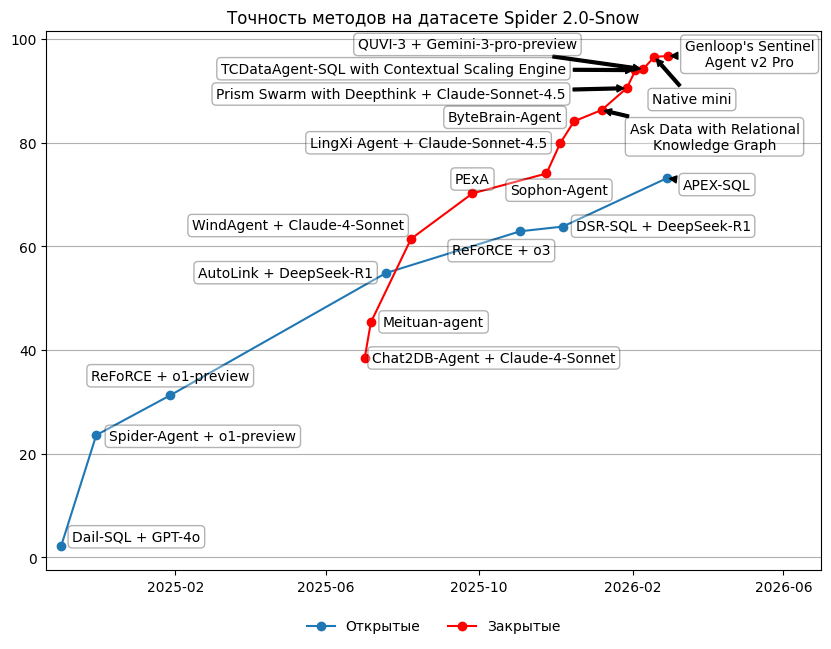

In [25]:
from datetime import date, timedelta
import matplotlib.dates as mdates

s2snow_data = [
    (date(2024, 11, 2), 2.20, "Dail-SQL + GPT-4o", 'open'),
    (date(2024, 11, 30), 23.58, "Spider-Agent + o1-preview", 'open'),
    (date(2025, 1, 28), 31.26, "ReFoRCE + o1-preview", 'open'),
    (date(2025, 7, 2), 38.39, "Chat2DB-Agent + Claude-4-Sonnet", 'closed'),
    (date(2025, 7, 7), 45.34, "Meituan-agent", 'closed'),
    (date(2025, 7, 19), 54.84, "AutoLink + DeepSeek-R1", 'open'),
    (date(2025, 8, 8), 61.43, "WindAgent + Claude-4-Sonnet", 'closed'),
    (date(2025, 9, 26), 70.20, "PExA", 'closed'),
    (date(2025, 11, 3), 62.89, "ReFoRCE + o3", 'open'),
    (date(2025, 11, 24), 74.04, "Sophon-Agent", 'closed'),
    (date(2025, 12, 5), 79.89, "LingXi Agent + Claude-Sonnet-4.5", 'closed'),
    (date(2025, 12, 7), 63.80, "DSR-SQL + DeepSeek-R1", 'open'),
    (date(2025, 12, 16), 84.10, "ByteBrain-Agent", 'closed'),
    (date(2026, 1, 7), 86.28, "Ask Data with Relational\nKnowledge Graph", 'closed'),
    (date(2026, 1, 27), 90.49, "Prism Swarm with Deepthink + Claude-Sonnet-4.5", 'closed'),
    (date(2026, 2, 3), 93.97, "TCDataAgent-SQL with Contextual Scaling Engine", 'closed'),
    (date(2026, 2, 9), 94.15, "QUVI-3 + Gemini-3-pro-preview", 'closed'),
    (date(2026, 2, 18), 96.53, "Native mini", 'closed'),
    (date(2026, 2, 28), 73.13, "APEX-SQL", 'open'),
    (date(2026, 3, 1), 96.70, "Genloop's Sentinel\nAgent v2 Pro", 'closed')
]

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    [line[0] for line in s2snow_data if line[3] == 'open'], 
    [line[1] for line in s2snow_data if line[3] == 'open'],
    marker='o', label='Открытые'
)
ax.plot(
    [line[0] for line in s2snow_data if line[3] == 'closed'], 
    [line[1] for line in s2snow_data if line[3] == 'closed'],
    marker='o', label='Закрытые', color='red'
)

offsets = [
    (timedelta(days=60), 1),
    (timedelta(days=85), -1),
    (timedelta(days=0), 3),
    (timedelta(days=103), -0.7),
    (timedelta(days=50), -0.7),
    (-timedelta(days=80), -0.7),
    (-timedelta(days=90), 1.8),
    (timedelta(days=0), 2),
    (-timedelta(days=15), -4.5),
    (timedelta(days=10), -4),
    (-timedelta(days=105), -0.7),
    (timedelta(days=80), -0.7),
    (-timedelta(days=55), 0),
    (timedelta(days=90), -7.5),
    (-timedelta(days=188), -1.9),
    (-timedelta(days=193), -0.5),
    (-timedelta(days=140), 4),
    (timedelta(days=30), -9),
    (timedelta(days=40), -2),
    (timedelta(days=65), -2),
]
for i, line in enumerate(s2snow_data[:-7]):
    if i < len(offsets):
        ax.text(
            line[0] + offsets[i][0], line[1] + offsets[i][1], line[2], ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3)
        )
    else:
        ax.text(
            line[0], line[1], line[2], ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3)
        )

for i, line in enumerate(s2snow_data[-7:]):
    idx = i + len(s2snow_data) - 7
    if idx < len(offsets):
        ax.annotate(
            line[2], xy=(line[0], line[1]),
            xytext=(line[0] + offsets[idx][0], line[1] + offsets[idx][1]), ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3),
            arrowprops=dict(arrowstyle='simple', color='black')
        )
    else:
        ax.annotate(
            line[2], xy=(line[0], line[1]),
            xytext=(line[0], line[1]), ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3),
            arrowprops=dict(arrowstyle='simple', color='black')
        )


ax.grid(True, axis='y')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title("Точность методов на датасете Spider 2.0-Snow")
# ax.set_ylim(57, 87)
ax.set_xlim(s2snow_data[0][0] - timedelta(days=12), date(2026, 7, 1))
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False);

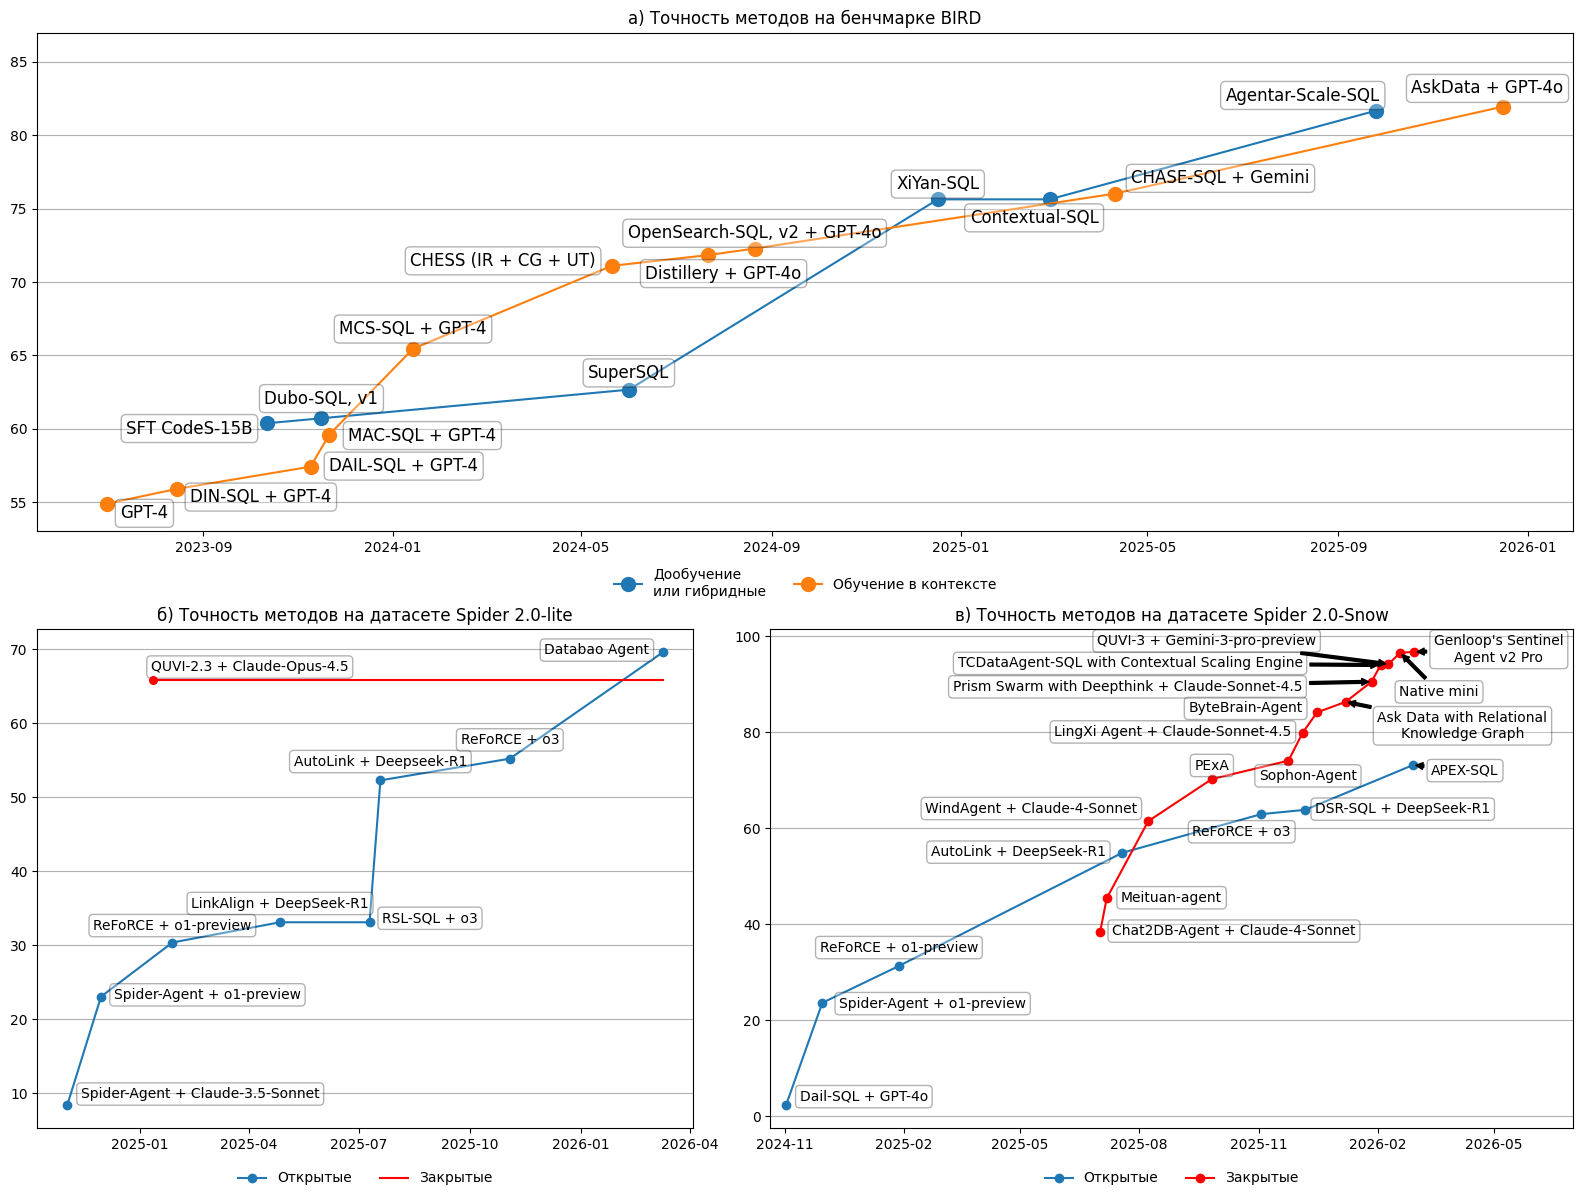

In [72]:
plt.figure(figsize=(16, 12))

ax = plt.subplot(2, 1, 1)

ax.plot(
    [line[0] for line in bird_data if line[3] == 'ft'], 
    [line[1] for line in bird_data if line[3] == 'ft'],
    marker='o', label='Дообучение\nили гибридные', markersize=10
)
ax.plot(
    [line[0] for line in bird_data if line[3] == 'icl'], 
    [line[1] for line in bird_data if line[3] == 'icl'],
    marker='o', label='Обучение в контексте', markersize=10
)

offsets = [
    (timedelta(days=24), -1),
    (timedelta(days=54), -0.9),
    (-timedelta(days=50), -0.7),
    (timedelta(days=60), -0.3),
    (timedelta(days=0), 1),
    (timedelta(days=60), -0.4),
    (timedelta(days=0), 1),
    (-timedelta(days=70), 0),
    (timedelta(days=0), 0.8),
    (timedelta(days=10), -1.6),
    (timedelta(days=0), 0.7),
    (-timedelta(days=0), 0.7),
    (timedelta(days=-10), -1.6),
    (timedelta(days=68), 0.7),
    (-timedelta(days=47), 0.7),
    (-timedelta(days=10), 0.9),
]
for i, line in enumerate(bird_data):
    if i < len(offsets):
        ax.text(
            line[0] + offsets[i][0], line[1] + offsets[i][1], line[2], ha='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3)
        )
    else:
        ax.text(
            line[0], line[1], line[2], ha='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3)
        )

ax.grid(True, axis='y')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title("а) Точность методов на бенчмарке BIRD")
ax.set_ylim(53, 87)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False);


ax = plt.subplot(2, 11, (12, 16))

ax.plot(
    [line[0] for line in s2lite_data if line[3] == 'open'], 
    [line[1] for line in s2lite_data if line[3] == 'open'],
    marker='o', label='Открытые'
)
ax.plot(
    [s2lite_data[i][0] for i in range(2, len(s2lite_data))],
    [s2lite_data[2][1] for _ in range(2, len(s2lite_data))],
    label='Закрытые', color='red'
)
ax.scatter(s2lite_data[2][0], s2lite_data[2][1], color='red', s=30, zorder=5)


offsets = [
    (timedelta(days=110), 1),
    (timedelta(days=88), -0.3),
    (timedelta(days=80), 1.25),
    (timedelta(days=0), 1.75),
    (timedelta(days=0), 2),
    (timedelta(days=50), 0),
    (timedelta(days=0), 2),
    (timedelta(days=0), 2),
    (-timedelta(days=55), -0.3),
]
for i, line in enumerate(s2lite_data):
    if i < len(offsets):
        ax.text(
            line[0] + offsets[i][0], line[1] + offsets[i][1], line[2], ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3)
        )
    else:
        ax.text(
            line[0], line[1], line[2], ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3)
        )


ax.grid(True, axis='y')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title("б) Точность методов на датасете Spider 2.0-lite")
# ax.set_ylim(57, 87)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False);



ax = plt.subplot(2, 11, (17, 22))

ax.plot(
    [line[0] for line in s2snow_data if line[3] == 'open'], 
    [line[1] for line in s2snow_data if line[3] == 'open'],
    marker='o', label='Открытые'
)
ax.plot(
    [line[0] for line in s2snow_data if line[3] == 'closed'], 
    [line[1] for line in s2snow_data if line[3] == 'closed'],
    marker='o', label='Закрытые', color='red'
)

offsets = [
    (timedelta(days=60), 1),
    (timedelta(days=85), -1),
    (timedelta(days=0), 3),
    (timedelta(days=103), -0.7),
    (timedelta(days=50), -0.7),
    (-timedelta(days=80), -0.7),
    (-timedelta(days=90), 1.8),
    (timedelta(days=0), 2),
    (-timedelta(days=15), -4.5),
    (timedelta(days=15), -4),
    (-timedelta(days=100), -0.7),
    (timedelta(days=75), -0.7), # 
    (-timedelta(days=55), 0),
    (timedelta(days=90), -7.5),
    (-timedelta(days=188), -1.9),
    (-timedelta(days=193), -0.5),
    (-timedelta(days=140), 4),
    (timedelta(days=30), -9),
    (timedelta(days=40), -2),
    (timedelta(days=65), -2),
]
for i, line in enumerate(s2snow_data[:-7]):
    if i < len(offsets):
        ax.text(
            line[0] + offsets[i][0], line[1] + offsets[i][1], line[2], ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3)
        )
    else:
        ax.text(
            line[0], line[1], line[2], ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3)
        )

for i, line in enumerate(s2snow_data[-7:]):
    idx = i + len(s2snow_data) - 7
    if idx < len(offsets):
        ax.annotate(
            line[2], xy=(line[0], line[1]),
            xytext=(line[0] + offsets[idx][0], line[1] + offsets[idx][1]), ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3),
            arrowprops=dict(arrowstyle='simple', color='black')
        )
    else:
        ax.annotate(
            line[2], xy=(line[0], line[1]),
            xytext=(line[0], line[1]), ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3),
            arrowprops=dict(arrowstyle='simple', color='black')
        )


ax.grid(True, axis='y')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title("в) Точность методов на датасете Spider 2.0-Snow")
# ax.set_ylim(57, 87)
ax.set_xlim(s2snow_data[0][0] - timedelta(days=12), date(2026, 7, 1))
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False);

plt.tight_layout()

## График бенчмарков

In [29]:
data = """| Бенчмарк          | Общее число результатов | Число результатов с 2025 года | Год появления |
| ----------------- | ----------------------- | ----------------------------- | ------------- |
| ATIS              | 175                     | 44                            | 1994          |
| GeoQuery          | 151                     | 31                            | 1996          |
| Restaurants       | 114                     | 25                            | 2000          |
| IMDb              | 105                     | 20                            | 2017          |
| Yelp              | 99                      | 17                            | 2017          |
| WikiSQL           | 467                     | 156                           | 2017          |
| Advising          | 63                      | 14                            | 2018          |
| Spider            | 908                     | 482                           | 2018          |
| SParC             | 160                     | 45                            | 2019          |
| CoSQL             | 165                     | 55                            | 2019          |
| CSpider           | 65                      | 18                            | 2019          |
| MIMICSQL          | 50                      | 23                            | 2020          |
| SQUALL            | 41                      | 9                             | 2020          |
| FIBEN             | 37                      | 14                            | 2020          |
| DuSQL             | 64                      | 16                            | 2020          |
| CHASE^1           | 64                      | 16                            | 2021          |
| *Spider-Syn       | 135                     | 69                            | 2021          |
| *Spider-DK        | 116                     | 62                            | 2021          |
| *Spider-Realistic | 106                     | 56                            | 2021          |
| KaggleDBQA        | 103                     | 46                            | 2021          |
| SEDE              | 31                      | 14                            | 2021          |
| *MT-TEQL          | 24                      | 11                            | 2021          |
| *Dr.Spider        | 61                      | 38                            | 2023          |
| BIRD              | 491                     | 365                           | 2023          |
| AmbiQT            | 21                      | 19                            | 2023          |
| ScienceBenchmark  | 55                      | 36                            | 2024          |
| BULL              | 41                      | 14                            | 2024          |
| Spider2           | 38                      | 34                            | 2024          |"""

data = [tuple(cell.strip() for cell in line[1:-1].strip().split(' | ')) for line in data.split('\n')[2:]]
data = [tuple(int(cell) if cell.isdigit() else cell for cell in line) for line in data]
data

[('ATIS', 175, 44, 1994),
 ('GeoQuery', 151, 31, 1996),
 ('Restaurants', 114, 25, 2000),
 ('IMDb', 105, 20, 2017),
 ('Yelp', 99, 17, 2017),
 ('WikiSQL', 467, 156, 2017),
 ('Advising', 63, 14, 2018),
 ('Spider', 908, 482, 2018),
 ('SParC', 160, 45, 2019),
 ('CoSQL', 165, 55, 2019),
 ('CSpider', 65, 18, 2019),
 ('MIMICSQL', 50, 23, 2020),
 ('SQUALL', 41, 9, 2020),
 ('FIBEN', 37, 14, 2020),
 ('DuSQL', 64, 16, 2020),
 ('CHASE^1', 64, 16, 2021),
 ('*Spider-Syn', 135, 69, 2021),
 ('*Spider-DK', 116, 62, 2021),
 ('*Spider-Realistic', 106, 56, 2021),
 ('KaggleDBQA', 103, 46, 2021),
 ('SEDE', 31, 14, 2021),
 ('*MT-TEQL', 24, 11, 2021),
 ('*Dr.Spider', 61, 38, 2023),
 ('BIRD', 491, 365, 2023),
 ('AmbiQT', 21, 19, 2023),
 ('ScienceBenchmark', 55, 36, 2024),
 ('BULL', 41, 14, 2024),
 ('Spider2', 38, 34, 2024)]

In [30]:
data.sort(key=lambda x: x[2])

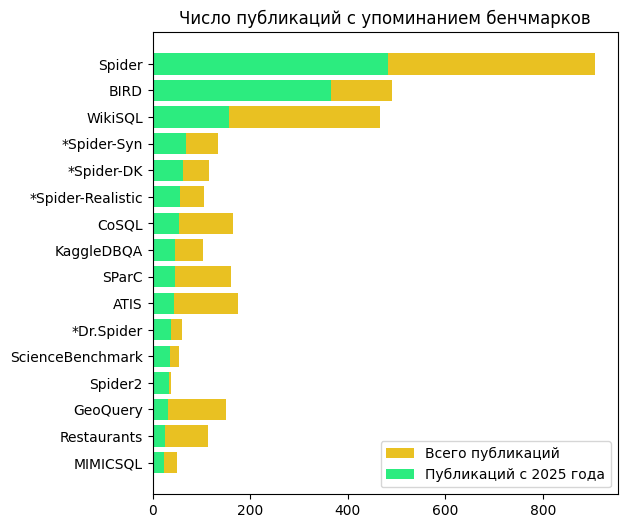

In [31]:
plt.figure(figsize=(6, 6))
plt.barh([line[0] for line in data if line[2] > 20], [line[1] for line in data if line[2] > 20], color="#E9C122", label="Всего публикаций")
plt.barh([line[0] for line in data if line[2] > 20], [line[2] for line in data if line[2] > 20], color="#2CEC7F", label="Публикаций с 2025 года")
plt.title("Число публикаций с упоминанием бенчмарков")
plt.legend();